# Surface diffusion energy barriers with NEB

This notebook follows the [official ASE surface-diffusion NEB tutorial](https://docs.ase-lib.org/examples_generated/03-tutorials/diffusion_neb.html). It constructs an Au adatom on Al(001), relaxes two neighboring adsorption states, connects them with a nudged elastic band (NEB), analyzes the barrier, restarts the band with a tighter force tolerance, and outlines parallelization over images.

NEB approximates a minimum-energy path between known initial and final states. The forward diffusion barrier is the energy difference between the path maximum and the initial minimum:

$$
E_{\mathrm{f}}^{\ddagger} = E_{\mathrm{max}} - E_{\mathrm{initial}}.
$$

### Learning goals

- prepare independently relaxed endpoint structures with matching atoms, cells, and constraints;
- create and interpolate a multi-image NEB band;
- distinguish physical forces, spring forces, and the NEB residual;
- extract forward and reverse barriers, reaction energy, and force convergence;
- restart a saved band with a tighter threshold; and
- understand when image-parallel execution is useful.

Unless stated otherwise, distances are in ångström (Å), energies in electronvolts (eV), and forces in eV/Å.

In [1]:
import matplotlib.pyplot as plt

from ase.build import add_adsorbate, fcc100
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.io import read
from ase.mep import NEB
from ase.optimize import BFGS, QuasiNewton
from ase.parallel import world
from ase.visualize.plot import plot_atoms

## Building the initial adsorption state

`fcc100('Al', size=(2, 2, 3))` creates a three-layer $2 \times 2$ Al(001) slab. `add_adsorbate()` places one Au atom 1.7 Å above a fourfold hollow site, giving 12 Al atoms and one adsorbate. `center(axis=2, vacuum=4.0)` adds 4 Å of vacuum between the outermost atoms and each boundary along the nonperiodic surface-normal direction.

The static plot is an assembly check: the adatom should sit above the intended site, the slab should have three layers, and the vacuum should separate periodic slab replicas along $z$.

In [2]:
slab = fcc100('Al', size=(2, 2, 3))
add_adsorbate(slab, 'Au', 1.7, 'hollow')
slab.center(axis=2, vacuum=4.0)

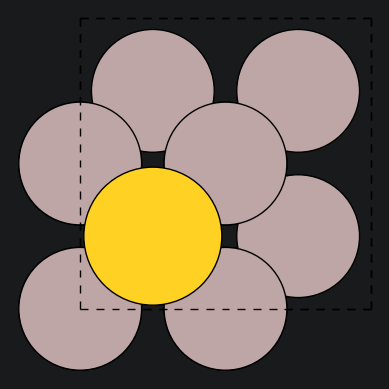

In [3]:
fig, ax = plt.subplots()
plot_atoms(slab, ax)
ax.set_axis_off()

## Constraining the deeper slab layers

ASE surface builders assign layer tags: the Au adsorbate has tag 0, the top Al layer has tag 1, and deeper layers have larger tags. The mask `atom.tag > 1` therefore fixes the second and third Al layers while leaving the top four Al atoms and Au free to move. The printed mask contains eight `True` values and five `False` values, consistent with that partition.

Every NEB image must use the same constraint pattern. Otherwise, neighboring images would represent different numbers of degrees of freedom and the band forces would not describe one consistent pathway.

In [4]:
mask = [atom.tag > 1 for atom in slab]
print(mask)
slab.set_constraint(FixAtoms(mask=mask))

[np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.False_, np.False_, np.False_, np.False_, np.False_]


## Relaxing the endpoint structures

EMT supplies inexpensive model energies and forces for this Al-Au example. It is suitable for learning the NEB workflow, but the resulting barrier should not be interpreted as a converged first-principles prediction.

The initial endpoint is relaxed with `QuasiNewton` until the largest force on the movable atoms is below 0.05 eV/Å. The final image in `initial.traj` has an energy of approximately 3.314754 eV and a maximum force of 0.0378 eV/Å. Relaxing endpoints before interpolation prevents ordinary endpoint strain from being mistaken for part of the diffusion barrier.

In [5]:
slab.calc = EMT()

In [6]:
qn = QuasiNewton(slab, trajectory='../files/advanced/tutorial_08/initial.traj')
qn.run(fmax=0.05)

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 20:20:15        3.323870       0.2462
BFGSLineSearch:    1[  1] 20:20:15        3.314754       0.0378


np.True_

### Creating the final adsorption state

The Au atom is translated by half the surface-cell length along $x$, moving it toward the neighboring symmetry-related hollow site. A second independent relaxation is saved to `final.traj`. Its final energy is approximately 3.316117 eV, only about 0.001363 eV above the initial state.

The small nonzero endpoint difference measures residual numerical and relaxation asymmetry in this nominally equivalent hop. It is useful to report because it also determines the difference between the forward and reverse barrier estimates.

In [7]:
slab[-1].x += slab.get_cell()[0, 0] / 2
qn = QuasiNewton(slab, trajectory='../files/advanced/tutorial_08/final.traj')
qn.run(fmax=0.05)

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 20:20:15        3.320051       0.1208
BFGSLineSearch:    1[  1] 20:20:15        3.316117       0.0474


np.True_

## Constructing and optimizing the NEB band

The band contains five images: two relaxed endpoints and three internal images copied from the initial state. Each internal image receives its own EMT calculator and the same fixed-layer constraint. `neb.interpolate()` then distributes their atomic positions linearly between the endpoints.

NEB minimizes the component of the physical force perpendicular to the path while spring forces maintain image spacing along the path. Schematically, the force on internal image $i$ is

$$
\mathbf{F}_i^{\mathrm{NEB}} = -\nabla V(\mathbf{R}_i)_{\perp} + \mathbf{F}_{i,\parallel}^{\mathrm{spring}}.
$$

`method='improvedtangent'` selects ASE's recommended tangent construction. BFGS optimizes the three internal images until the largest NEB residual is below 0.05 eV/Å and writes every band iteration to `neb.traj`. This is a standard NEB, not yet a climbing-image calculation, so the highest image only approximates the saddle point.

In [8]:
initial = read('../files/advanced/tutorial_08/initial.traj')
final = read('../files/advanced/tutorial_08/final.traj')

constraint = FixAtoms(mask=[atom.tag > 1 for atom in initial])

images = [initial]
for i in range(3):
    image = initial.copy()
    image.calc = EMT()
    image.set_constraint(constraint)
    images.append(image)

images.append(final)

neb = NEB(images, method='improvedtangent')
neb.interpolate()
qn = BFGS(neb, trajectory='../files/advanced/tutorial_08/neb.traj')
qn.run(fmax=0.05)

      Step     Time          Energy          fmax
BFGS:    0 20:20:15        4.219952        3.520752
BFGS:    1 20:20:15        3.937039        2.176460
BFGS:    2 20:20:15        3.719814        0.435144
BFGS:    3 20:20:15        3.709652        0.230134
BFGS:    4 20:20:15        3.708878        0.244118
BFGS:    5 20:20:15        3.706087        0.257725
BFGS:    6 20:20:15        3.698531        0.213294
BFGS:    7 20:20:15        3.692120        0.246238
BFGS:    8 20:20:15        3.692278        0.187553
BFGS:    9 20:20:15        3.693494        0.172952
BFGS:   10 20:20:15        3.692670        0.151720
BFGS:   11 20:20:15        3.690813        0.073884
BFGS:   12 20:20:15        3.690200        0.071211
BFGS:   13 20:20:15        3.690380        0.078122
BFGS:   14 20:20:15        3.690427        0.103668
BFGS:   15 20:20:15        3.689897        0.100381
BFGS:   16 20:20:15        3.689034        0.055057
BFGS:   17 20:20:15        3.688737        0.028898


np.True_

### Coarse-band convergence

The stored optimization reaches a maximum NEB residual of approximately 0.0289 eV/Å after 17 BFGS steps, satisfying the requested 0.05 eV/Å threshold. The substantial drop from 3.52 eV/Å at the interpolated starting band shows why the internal images must be optimized rather than treated as a simple geometric interpolation.

The following plot shows only the relaxed final endpoint. To inspect the full diffusion band, the trajectory selector must load one complete group of five images.

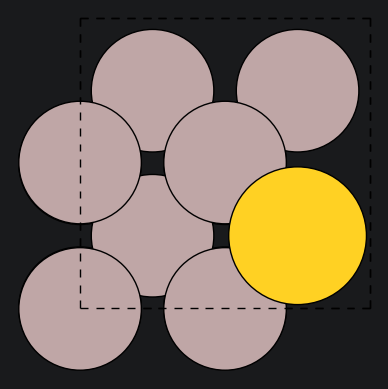

In [9]:
fig, ax = plt.subplots()
plot_atoms(final, ax)
ax.set_axis_off()

## Visualizing the final band

A BFGS NEB trajectory stores all images for every optimization step. Because this calculation has five images, the ASE selector `@-5:` retrieves the final complete band rather than the final five optimizer steps. From the `official_tutorials_advanced` directory, it can be opened with:

```bash
ase gui ../files/advanced/tutorial_08/neb.traj@-5:
```

The GUI's **Tools → NEB** view displays the energy profile. `ase nebplot --share-x --share-y` can instead create a sequence of band plots across the optimization history. The number in the selector must always match the number of images in the saved band.

In [10]:
import matplotlib.pyplot as plt

from ase.io import read
from ase.mep import NEBTools

images = read('../files/advanced/tutorial_08/neb.traj@-5:')

nebtools = NEBTools(images)

## Analyzing the band with `NEBTools`

`NEBTools` treats the last five structures as one band. `get_barrier(fit=False)` uses the highest discrete image without fitting between images and returns two values:

$$
E_{\mathrm{f}}^{\ddagger} = E_{\mathrm{highest\ image}} - E_{\mathrm{initial}},
$$

$$
\Delta E = E_{\mathrm{final}} - E_{\mathrm{initial}}.
$$

For the stored five-image serial band, `Ef` is approximately 0.37398 eV and `dE` is approximately 0.001363 eV. The corresponding reverse barrier is $E_{\mathrm{r}}^{\ddagger}=E_{\mathrm{f}}^{\ddagger}-\Delta E$, approximately 0.37262 eV. Because no climbing image is used, these are image-resolution-dependent estimates rather than a fully localized saddle-point energy.

In [11]:
Ef, dE = nebtools.get_barrier(fit=False)

### Checking the NEB residual

`get_fmax()` evaluates the largest force norm used by an NEB optimizer. The stored coarse band gives `max_force ≈ 0.02890` eV/Å, consistent with the optimizer log and below the 0.05 eV/Å stopping threshold. The cell assigns this number to a variable without displaying it; evaluating `max_force` or printing it would make the convergence evidence visible.

With ASE 3.29, this helper emits a method-transition warning because `NEBTools.get_fmax()` internally creates an `NEB` object without passing a method. The main optimizations in this notebook explicitly use `method='improvedtangent'`; the warning does not mean that those optimizations used the older `aseneb` method.

In [12]:
max_force = nebtools.get_fmax()

/Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/ase/mep/neb.py:329: UserWarning: The default method has changed from 'aseneb' to 'improvedtangent'. The 'aseneb' method is an unpublished, custom implementation that is not recommended as it frequently results in very poor bands. Please explicitly set method='improvedtangent' to silence this warning, or set method='aseneb' if you strictly require the old behavior (results may vary). See: https://gitlab.com/ase/ase/-/merge_requests/3952
  warnings.warn(


### Plotting and interpreting the energy profile

`plot_band()` shifts the first image to 0 eV and plots image energies against cumulative configuration-space path length in Å. For this simple hop, that path coordinate is dominated by the Au displacement along $x$, but it also includes relaxation of the movable Al atoms.

The blue points are the five calculated images. The smooth black curve is an interpolation used for visualization, and the green line segments indicate tangents at the images. The plotted fit gives a forward barrier near 0.374 eV and a reverse barrier near 0.373 eV. The near-zero reaction energy is expected for diffusion between symmetry-related hollow sites.

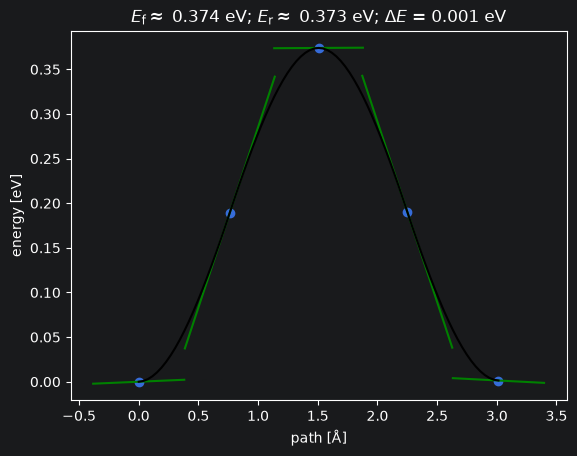

In [13]:
fig = nebtools.plot_band()

## Restarting with tighter convergence

A practical NEB workflow often uses a loose first relaxation to establish the path, followed by a tighter restart. The selector `@-5:` loads the last complete five-image band from the serial trajectory. Calculators are reattached to the three internal images; the endpoints retain their stored single-point energies. The same improved-tangent formulation is then relaxed to `fmax=0.005 eV/Å` and written to a separate restart trajectory.

This restart assumes that `neb.traj` still contains the five-image serial calculation. If the number of images changes, the trajectory slice must change with it.

In [14]:
images = read('../files/advanced/tutorial_08/neb.traj@-5:')

for i in range(1, len(images) - 1):
    images[i].calc = EMT()

neb = NEB(images, method='improvedtangent')
qn = BFGS(neb, trajectory='../files/advanced/tutorial_08/neb_restart.traj')
qn.run(fmax=0.005)

      Step     Time          Energy          fmax
BFGS:    0 20:20:16        3.688737        0.028898
BFGS:    1 20:20:16        3.688734        0.026547
BFGS:    2 20:20:16        3.688731        0.021515
BFGS:    3 20:20:16        3.688730        0.021379
BFGS:    4 20:20:16        3.688718        0.009577
BFGS:    5 20:20:16        3.688718        0.008389
BFGS:    6 20:20:16        3.688718        0.009122
BFGS:    7 20:20:16        3.688718        0.009290
BFGS:    8 20:20:16        3.688716        0.007568
BFGS:    9 20:20:16        3.688714        0.005563
BFGS:   10 20:20:16        3.688715        0.002547


np.True_

### Tighter result

For the stored run, ten additional BFGS steps reduce the NEB force from about `0.0289 eV/Å` to `0.00255 eV/Å`. The discrete forward barrier changes only from approximately `0.373983 eV` to `0.373960 eV`, while the endpoint energy difference remains about `0.001363 eV`. The small change suggests that the coarse path was already close to the converged EMT result for this image spacing. It does not test convergence with respect to the number of images.

## Parallelizing over images

The force calculation for each internal image is independent, so ASE can distribute images across MPI ranks. The example below is a standalone parallel setup rather than a continuation of the five-image restart. It requires an MPI-aware Python environment and a calculator that can be used under MPI.

In a serial run, `n_images = 1` creates one internal image and therefore three images in total. To reproduce the earlier path with three internal images using three MPI ranks, set `n_images = 3` and launch with three ranks, as indicated by the code comment.

> **File-handling caution:** this example writes to `neb.traj`, the same filename used by the five-image serial calculation. Running it overwrites that earlier trajectory. Use a distinct name such as `neb_parallel.traj` before running both workflows in the same session.

In [15]:
initial = read('../files/advanced/tutorial_08/initial.traj')
final = read('../files/advanced/tutorial_08/final.traj')

constraint = FixAtoms(mask=[atom.tag > 1 for atom in initial])

n_images = 1  # Set to number of processes you use with mpiexec
images = [initial]
j = world.rank * n_images // world.size  # my image number
for i in range(n_images):
    image = initial.copy()
    if i == j:
        image.calc = EMT()
    image.set_constraint(constraint)
    images.append(image)
images.append(final)

neb = NEB(images, parallel=True, method='improvedtangent')
neb.interpolate()
qn = BFGS(neb, trajectory='../files/advanced/tutorial_08/neb.traj')
qn.run(fmax=0.05)

      Step     Time          Energy          fmax
BFGS:    0 20:20:16        4.219952        3.520752
BFGS:    1 20:20:16        3.937039        2.176459
BFGS:    2 20:20:16        3.730687        0.621235
BFGS:    3 20:20:16        3.710767        0.211379
BFGS:    4 20:20:16        3.707518        0.163942
BFGS:    5 20:20:16        3.704890        0.187028
BFGS:    6 20:20:16        3.699676        0.197511
BFGS:    7 20:20:16        3.694802        0.156084
BFGS:    8 20:20:16        3.691892        0.081850
BFGS:    9 20:20:16        3.691165        0.050493
BFGS:   10 20:20:16        3.690969        0.048196


np.True_

## Takeaways and possible extensions

This tutorial connects relaxed endpoint structures to a minimum-energy diffusion path and an activation barrier. The endpoints are constrained consistently, the internal images are interpolated and relaxed with NEB, and `NEBTools` converts the converged band into a barrier plot and numerical diagnostics.

The result remains tutorial-level. EMT is an inexpensive model; the slab is only a $2 \times 2$ lateral cell with three Al layers, only the upper layer is mobile, the vacuum is `4 Å` on each side, and the band has only three internal images. The initial endpoint relaxation and first NEB pass use `fmax=0.05 eV/Å`, the production path is not climbing-image NEB, and no slab-size, image-count, or calculator-convergence study is included. The numerical barrier should therefore be interpreted as a demonstration of the workflow rather than a quantitatively converged Au/Al(001) prediction.

The most valuable next addition would be a **climbing-image NEB restart** with more internal images and tighter force convergence. Setting `climb=True` only after an ordinary NEB has produced a smooth path helps the highest-energy image approach the saddle point. I would then add:

1. an image-count study using, for example, 3, 5, and 7 internal images, with linear and IDPP interpolation compared;
2. explicit printing and CSV export of $E_\mathrm{f}^\ddagger$, $E_\mathrm{r}^\ddagger$, $\Delta E$, and the final NEB force, plus a saved barrier figure;
3. distinct filenames for the serial, restart, and MPI trajectories so later examples cannot overwrite earlier results;
4. a constrained Au-displacement scan in both directions, plotted against the actual Au displacement, as a check on this unusually simple path;
5. convergence checks for lateral cell size, slab thickness, vacuum, relaxed substrate layers, and eventually a higher-accuracy calculator;
6. an inline animation of the final band and simple geometric diagnostics such as Au displacement and nearest Au–Al distances along the path.

For this particular example, the reaction coordinate is essentially the Au $x$ displacement, so the official ASE tutorial notes that NEB is more machinery than strictly necessary. That makes a comparison with the constrained scan especially instructive: the scan tests a chosen coordinate, whereas NEB allows the full set of unconstrained degrees of freedom to relax perpendicular to the path.

A later extension could connect the barrier to a transition-state-theory estimate,

$$
k(T) \approx \nu \exp\left(-\frac{E^\ddagger}{k_\mathrm{B}T}\right),
$$

but a defensible rate also requires an attempt frequency $\nu$ rather than the barrier alone.